In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from derivatives import EuropeanCall, EuropeanPut, EuropeanCallGreeks, AmericanPut, AsianCall
from portfolio import EquityPosition, Portfolio
from yieldcurve import YieldCurve, load_rba_yield_curve

# Data Overview

In [2]:
from pathlib import Path

# ── Load BHP Data ─────────────────────────────────────
bhp = pd.read_csv("../data/Market_Data_BHP_prices.csv", parse_dates=["Date"])
bhp = bhp.sort_values("Date").reset_index(drop=True)

# Compute daily returns
bhp["Return"] = bhp["Close"].pct_change()
bhp_returns   = bhp["Return"].dropna()

# Key parameters from the data
S0    = bhp["Close"].iloc[-1]          # Latest closing price (57.33)
sigma = bhp_returns.std() * np.sqrt(252)  # Annualised historical volatility
K     = round(S0)                      # ATM strike, rounded to nearest dollar
T     = 1.0                            # 1-year expiry

print(f"S0    = ${S0:.2f}")
print(f"K     = ${K:.2f}")
print(f"T     = {T} year")
print(f"sigma = {sigma:.4f} ({sigma*100:.2f}%)")


S0    = $57.33
K     = $57.00
T     = 1.0 year
sigma = 0.2492 (24.92%)


In [3]:
# Construct Yield Curve from RBA data CSV
# Use the loader in src/yieldcurve.py to read the RBA f2 dataset.
rba_csv = "../data/f2-data.csv"
yc = load_rba_yield_curve(rba_csv)
# yc = YieldCurve(maturities, zero_rates)  # fallback manual curve

Using yield curve data from: 07-May-2026


# Manual validation test
This is a quick manual validation section. It uses a fixed, manually specified yield curve and a simple European option pricing example to sanity-check the pricing functions independently of the main BHP dataset.

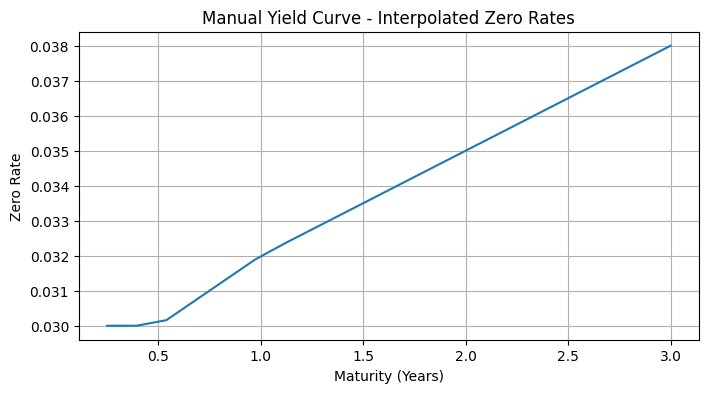

In [4]:
# Manual validation yield curve
manual_maturities = [0.5, 1.0, 2.0, 3.0]
manual_zero_rates = [0.03, 0.032, 0.035, 0.038]
yc_manual = YieldCurve(manual_maturities, manual_zero_rates)

manual_test_maturities = np.linspace(0.25, 3.0, 20)
manual_rates = [yc_manual.get_zero_rate(T) for T in manual_test_maturities]
manual_dfs = [yc_manual.get_discount_factor(T) for T in manual_test_maturities]

plt.figure(figsize=(8,4))
plt.plot(manual_test_maturities, manual_rates)
plt.title("Manual Yield Curve - Interpolated Zero Rates")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show()

In [5]:
# Manual validation option pricing test
manual_S0 = 100
manual_K = 100
manual_T = 1.0
manual_sigma = 0.2

manual_call = EuropeanCall(
    S0=manual_S0,
    K=manual_K,
    T=manual_T,
    sigma=manual_sigma,
    yield_curve=yc_manual
)

manual_put = EuropeanPut(
    S0=manual_S0,
    K=manual_K,
    T=manual_T,
    sigma=manual_sigma,
    yield_curve=yc_manual
)

manual_call_price = float(round(manual_call.price(), 4))
manual_put_price = float(round(manual_put.price(), 4))

print(f"Manual test call price: ${manual_call_price}")
print(f"Manual test put price:  ${manual_put_price}")

Manual test call price: $9.5146
Manual test put price:  $6.3653


# Sanity Checks

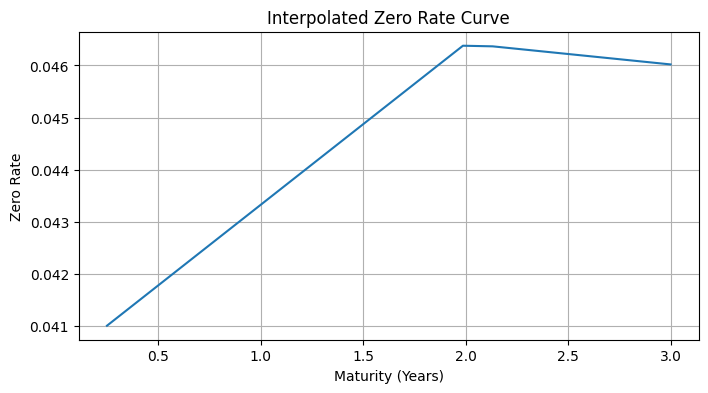

In [6]:
# sanity check on Yield Curve
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [yc.get_zero_rate(T) for T in test_maturities]
dfs = [yc.get_discount_factor(T) for T in test_maturities]

plt.figure(figsize=(8,4))
plt.plot(test_maturities,rates)
plt.title("Interpolated Zero Rate Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show()

# Option Parameters

In [7]:
# Use BHP market data
K = round(S0)  # at-the-money strike (rounded to nearest dollar)
T = 1.0  # 1 year to maturity

print(f"Option Parameters:")
print(f" S0 = ${S0:.2f} (BHP closing Price)")
print(f" K = ${K:.2f} (at-the-money strike)")
print(f" T = {T} year")
print(f" sigma = {sigma:.2%} (historical volatility)")

call = EuropeanCall(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc)
put = EuropeanPut(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc)

Option Parameters:
 S0 = $57.33 (BHP closing Price)
 K = $57.00 (at-the-money strike)
 T = 1.0 year
 sigma = 24.92% (historical volatility)


# European Call and European Put Option Prices

In [8]:
# European Call Price and European Put Price 
call_price = float(round(call.price(), 4))
put_price = float(round(put.price(), 4))

print(f"The call price is ${call_price}")
print(f"The put price is ${put_price}")

The call price is $7.0295
The put price is $4.2828


In [9]:
# ── 2. Create instrument objects ──────────────────────
equity = EquityPosition(ticker="BHP", spot=S0)

call = EuropeanCall(
    S0=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc
)

put = EuropeanPut(
    S0=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc
)

call_greeks = EuropeanCallGreeks(
    S0=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc
)

am_put = AmericanPut(
    S0=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc,
    steps=100
)

asian_call = AsianCall(
    S0=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc,
    simulations=10000
)

In [10]:
# ── 3. Sanity-check instrument pricing and delta ──────
print(f"Equity price: {round(equity.price(), 4)}")
print(f"Equity delta: {round(equity.delta(), 4)}")
print()
print(f"Call price:   {round(call.price(), 4)}")
print(f"Call delta:   {round(call.delta(), 4)}")
print()
print(f"Put price:    {round(put.price(), 4)}")
print(f"Put delta:    {round(put.delta(), 4)}")

Equity price: 57.33
Equity delta: 1.0

Call price:   7.0295
Call delta:   0.6261

Put price:    4.2828
Put delta:    -0.3739


In [11]:
# ── 4. Print full Greeks ──────────────────────────────
greeks = call_greeks.all_greeks()
print("=" * 45)
print("       EUROPEAN CALL OPTION - GREEKS")
print("=" * 45)
print(f"  {'Delta':<10} {greeks['delta']:>10.4f}   (price change per $1 move in S0)")
print(f"  {'Gamma':<10} {greeks['gamma']:>10.4f}   (rate of change of delta)")
print(f"  {'Theta':<10} {greeks['theta']:>10.4f}   (price decay per calendar day)")
print(f"  {'Vega':<10} {greeks['vega']:>10.4f}   (price change per 1% vol move)")
print(f"  {'Rho':<10} {greeks['rho']:>10.4f}   (price change per 1% rate move)")
print("=" * 45)

print("\n" + "=" * 45)
print("       AMERICAN PUT OPTION - PRICE")
print("=" * 45)
print(f"  {'Binomial Steps':<20} {am_put.steps:>10}")
print(f"  {'Price':<20} ${am_put.price():>9.4f}")
print(f"  {'Delta':<20} {am_put.delta():>10.4f}")
print(f"  {'Gamma':<20} {am_put.gamma():>10.4f}")
print(f"  {'Theta':<20} {am_put.theta():>10.4f}")
print(f"  {'Vega':<20} {am_put.vega():>10.4f}")
print("=" * 45)

print("\n" + "=" * 45)
print("       ASIAN CALL OPTION - MONTE CARLO")
print("=" * 45)
print(f"  {'Simulations':<20} {asian_call.simulations:>10,}")
print(f"  {'Steps':<20} {asian_call.steps:>10}")
print(f"  {'Price':<20} ${asian_call.price():>9.4f}")
print(f"  {'Delta':<20} {asian_call.delta():>10.4f}")
print(f"  {'Gamma':<20} {asian_call.gamma():>10.4f}")
print(f"  {'Theta':<20} {asian_call.theta():>10.4f}")
print(f"  {'Vega':<20} {asian_call.vega():>10.4f}")
print("=" * 45)

       EUROPEAN CALL OPTION - GREEKS
  Delta          0.6261   (price change per $1 move in S0)
  Gamma          0.0265   (rate of change of delta)
  Theta         -0.0108   (price decay per calendar day)
  Vega           0.2172   (price change per 1% vol move)
  Rho            0.2887   (price change per 1% rate move)

       AMERICAN PUT OPTION - PRICE
  Binomial Steps              100
  Price                $   4.5201
  Delta                   -0.3964
  Gamma                    0.0631
  Theta                   -0.0050
  Vega                     0.2172

       ASIAN CALL OPTION - MONTE CARLO
  Simulations              10,000
  Steps                       252
  Price                $   3.9474
  Delta                    0.5857
  Gamma                    0.0498
  Theta                   -0.0059
  Vega                     0.1222


In [12]:
# ── 5. Create the portfolio object ────────────────────
portfolio = Portfolio()

portfolio.add_position(equity, quantity=100,  label="Long BHP Equity")
portfolio.add_position(call,   quantity=10,   label="Long Call")
portfolio.add_position(put,    quantity=-5,   label="Short Put")

In [13]:
# ── 6. Show the portfolio position table ──────────────
position_df = portfolio.position_table()
position_df

,Position,Quantity,Unit Value,Position Value,Unit Delta,Position Delta
0,Long BHP Equity,100.0,57.330002,5733.000183,1.000000,100.000000
1,Long Call,10.0,7.029460,70.294601,0.626123,6.261235
2,Short Put,-5.0,4.282782,-21.413910,-0.373877,1.869383
3,TOTAL,NaN,NaN,5781.880874,NaN,108.130617


In [14]:
# ── 7. Compute core portfolio outputs ─────────────────
portfolio_value = portfolio.value()
portfolio_delta = portfolio.delta()

print("Portfolio Value:", round(portfolio_value, 2))
print("Portfolio Delta:", round(portfolio_delta, 4))

Portfolio Value: 5781.88
Portfolio Delta: 108.1306


In [15]:
# ── 8. Compute historical VaR using real BHP returns ──
hist_var_95 = portfolio.historical_var(bhp_returns, alpha=0.95, horizon_days=1)
hist_var_90 = portfolio.historical_var(bhp_returns, alpha=0.90, horizon_days=1)

print("Historical VaR (95%, 1-day):", round(hist_var_95, 2))
print("Historical VaR (90%, 1-day):", round(hist_var_90, 2))

Historical VaR (95%, 1-day): 141.47
Historical VaR (90%, 1-day): 105.44


In [16]:
# ── 9. Portfolio risk summary ─────────────────────────
risk_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Value",
        "Portfolio Delta",
        "Historical VaR (95%, 1-day)",
        "Historical VaR (90%, 1-day)"
    ],
    "Value": [
        portfolio_value,
        portfolio_delta,
        hist_var_95,
        hist_var_90
    ]
})

risk_summary

,Metric,Value
0,Portfolio Value,5781.880874
1,Portfolio Delta,108.130617
2,"Historical VaR (95%, 1-day)",141.469533
3,"Historical VaR (90%, 1-day)",105.442015


In [17]:
# ── 10. Scenario analysis ─────────────────────────────
# Scenario analysis is kept in the notebook, not the portfolio class.
# Each scenario rebuilds the portfolio under shocked inputs.

def shift_curve(base_curve, rate_shift):
    """Create a new yield curve with a simple parallel shift."""
    shocked_rates = [r + rate_shift for r in base_curve.zero_rates]
    shocked_curve = YieldCurve(
        maturities=base_curve.maturities,
        zero_rates=shocked_rates
    )
    return shocked_curve


def build_scenario_portfolio(base_curve, price_shock=0.0, rate_shift=0.0):
    """Rebuild the BHP portfolio under shocked inputs."""
    shocked_curve = shift_curve(base_curve, rate_shift)

    shocked_equity = EquityPosition(
        ticker="BHP",
        spot=equity.spot * (1 + price_shock)
    )

    shocked_call = EuropeanCall(
        S0=call.S0 * (1 + price_shock),
        K=call.K,
        T=call.T,
        sigma=call.sigma,
        yield_curve=shocked_curve
    )

    shocked_put = EuropeanPut(
        S0=put.S0 * (1 + price_shock),
        K=put.K,
        T=put.T,
        sigma=put.sigma,
        yield_curve=shocked_curve
    )

    shocked_portfolio = Portfolio()
    shocked_portfolio.add_position(shocked_equity, quantity=100,  label="Long BHP Equity")
    shocked_portfolio.add_position(shocked_call,   quantity=10,   label="Long Call")
    shocked_portfolio.add_position(shocked_put,    quantity=-5,   label="Short Put")

    return shocked_portfolio

In [18]:
# ── 11. Run scenarios ─────────────────────────────────
base_value = portfolio.value()

scenario_inputs = [
    {"Scenario": "Underlying +5%",  "price_shock":  0.05, "rate_shift":  0.0},
    {"Scenario": "Underlying -5%",  "price_shock": -0.05, "rate_shift":  0.0},
    {"Scenario": "Rates +50bps",    "price_shock":  0.0,  "rate_shift":  0.005},
    {"Scenario": "Rates -50bps",    "price_shock":  0.0,  "rate_shift": -0.005},
]

scenario_results = []

for s in scenario_inputs:
    shocked_portfolio = build_scenario_portfolio(
        base_curve=yc,
        price_shock=s["price_shock"],
        rate_shift=s["rate_shift"]
    )

    shocked_value = shocked_portfolio.value()
    pnl           = shocked_value - base_value
    pct_change    = pnl / base_value if base_value != 0 else np.nan

    scenario_results.append({
        "Scenario":      s["Scenario"],
        "Base Value":    base_value,
        "Shocked Value": shocked_value,
        "P&L":           pnl,
        "% Change":      pct_change
    })

scenario_df = pd.DataFrame(scenario_results)
scenario_df

,Scenario,Base Value,Shocked Value,P&L,% Change
0,Underlying +5%,5781.880874,6092.360313,310.479439,0.053699
1,Underlying -5%,5781.880874,5472.488759,-309.392115,-0.053511
2,Rates +50bps,5781.880874,5783.967331,2.086457,0.000361
3,Rates -50bps,5781.880874,5779.794879,-2.085995,-0.000361


# Sense Checks

- Volatilty should increase both prices
- Time to maturity should increase both prices as well (calls more than puts)
- S0 should increase call price, decrease put price
- K should increase put price, decrease put price

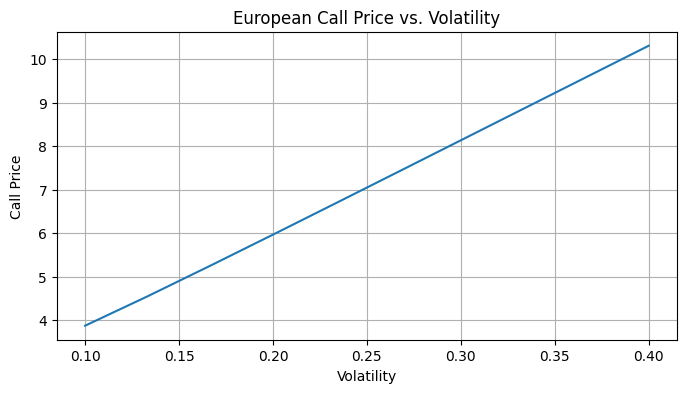

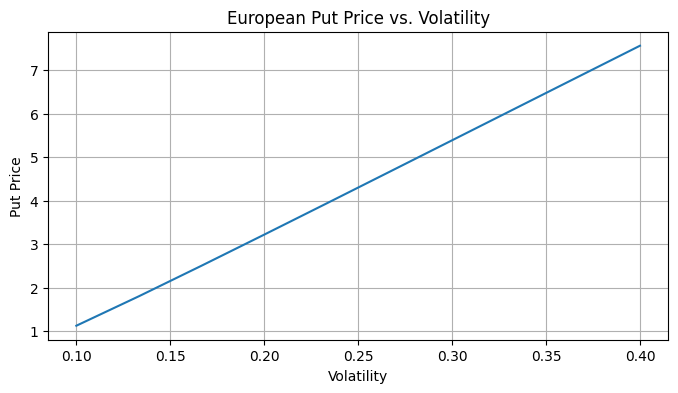

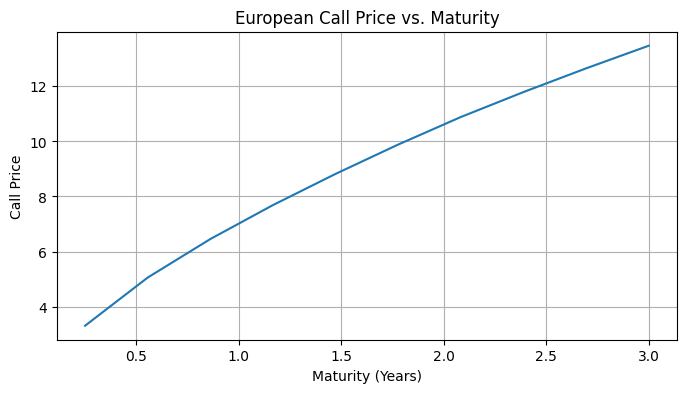

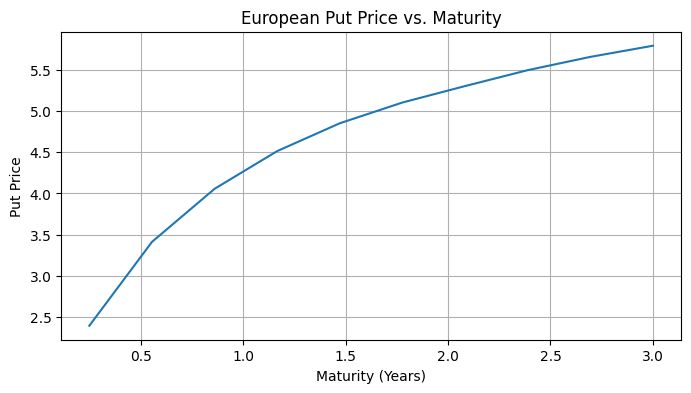

In [19]:
# Sense Checks
# 1. Volatility should increase both prices
vols = np.linspace(0.1, 0.4, 10)
call_prices = []
put_prices = []

for v in vols:
    tmp_call = EuropeanCall(S0=S0, K=K, T=T, sigma=v, yield_curve=yc)
    tmp_put  = EuropeanPut(S0=S0, K=K, T=T, sigma=v, yield_curve=yc)
    call_prices.append(tmp_call.price())
    put_prices.append(tmp_put.price())

plt.figure(figsize=(8,4))
plt.plot(vols, call_prices)
plt.title("European Call Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(vols, put_prices)
plt.title("European Put Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Put Price")
plt.grid(True)
plt.show()

# 2. Time to maturity should increase both prices
maturities = np.linspace(0.25, 3.0, 10)
call_prices_T = []
put_prices_T  = []

for t in maturities:
    tmp_call = EuropeanCall(S0=S0, K=K, T=t, sigma=sigma, yield_curve=yc)
    tmp_put  = EuropeanPut(S0=S0, K=K, T=t, sigma=sigma, yield_curve=yc)
    call_prices_T.append(tmp_call.price())
    put_prices_T.append(tmp_put.price())

plt.figure(figsize=(8,4))
plt.plot(maturities, call_prices_T)
plt.title("European Call Price vs. Maturity")
plt.xlabel("Maturity (Years)")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(maturities, put_prices_T)
plt.title("European Put Price vs. Maturity")
plt.xlabel("Maturity (Years)")
plt.ylabel("Put Price")
plt.grid(True)
plt.show()